In [1]:
! pip install tensorflow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import callbacks
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from keras import layers
from sklearn.metrics import r2_score


In [6]:
df=pd.read_csv("/content/Clean_Dataset.csv")
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [7]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [9]:
df.isnull()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,False,False,False,False,False,False,False,False,False,False,False,False
300149,False,False,False,False,False,False,False,False,False,False,False,False
300150,False,False,False,False,False,False,False,False,False,False,False,False
300151,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
300148,False
300149,False
300150,False
300151,False


In [14]:
df.isna().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [13]:
df.fillna(0, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [16]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


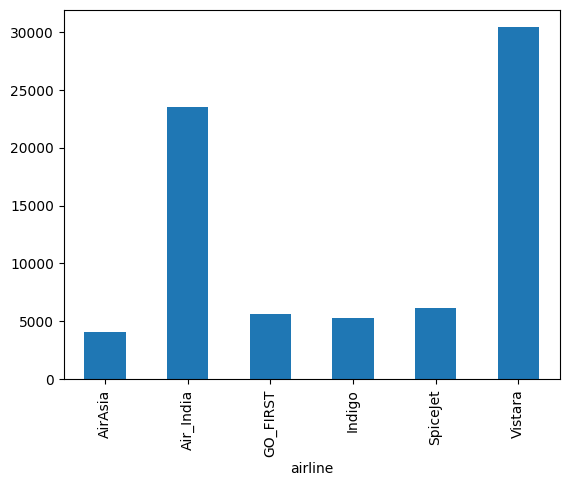

In [26]:
df.groupby('airline')['price'].mean().plot(kind='bar')
plt.show()

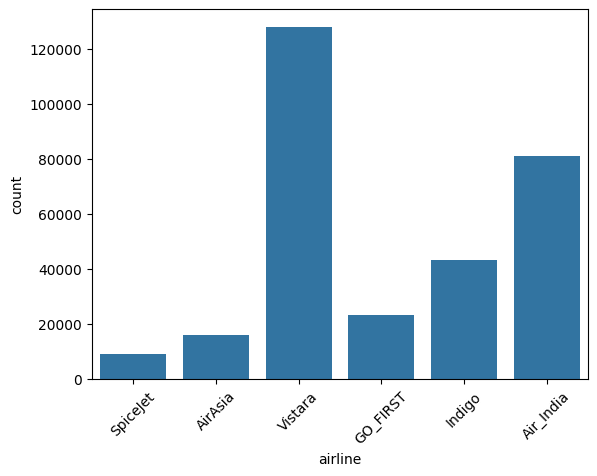

In [31]:
sns.countplot(x="airline",data=df)
plt.xticks(rotation=45)
plt.show()

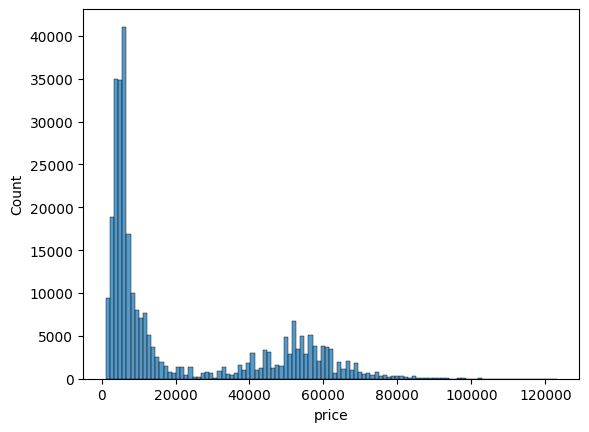

In [39]:
sns.histplot(df["price"])
plt.show()

In [40]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

cl = ["airline","flight" ,"source_city","departure_time","stops","arrival_time","destination_city","class"]
for col in cl:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [41]:
df


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,0,10.08,49,69265
300149,5,1481,1,0,0,5,3,0,10.42,49,77105
300150,5,1486,1,1,0,5,3,0,13.83,49,79099
300151,5,1483,1,1,0,2,3,0,10.00,49,81585


In [50]:

x = df.drop(columns=['price'])
y = df['price']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [52]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(240122, 10)
(60031, 10)
(240122,)
(60031,)


In [53]:
from keras.layers import Dropout, Input
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Dense(128, activation='relu',input_dim=10))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.compile(optimizer="adam",loss="mean_squared_error",metrics=["r2_score"])

In [56]:
history=model.fit(x_train,y_train,epochs=30,validation_split=0.2,batch_size=200)

Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 198803312.0000 - r2_score: 0.6144 - val_loss: 64043044.0000 - val_r2_score: 0.8752
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 190649088.0000 - r2_score: 0.6302 - val_loss: 124773304.0000 - val_r2_score: 0.7569
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 188119136.0000 - r2_score: 0.6351 - val_loss: 77364256.0000 - val_r2_score: 0.8493
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 185498320.0000 - r2_score: 0.6402 - val_loss: 60293824.0000 - val_r2_score: 0.8825
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 186152064.0000 - r2_score: 0.6389 - val_loss: 64632184.0000 - val_r2_score: 0.8741
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 184310448.0000 - r2_score: 0.6425 - val_loss: 89845088.0000 - val_r2_score: 0.8250
Epoch 7/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 180787088.0000 - r2_score: 0.6493 - val_loss: 68131232.0000 - val_r2_score: 0.867

In [57]:
y_pred=model.predict(x_test)

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [59]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,0,10.08,49,69265
300149,5,1481,1,0,0,5,3,0,10.42,49,77105
300150,5,1486,1,1,0,5,3,0,13.83,49,79099
300151,5,1483,1,1,0,2,3,0,10.00,49,81585


In [60]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print("R2_score=",r2)

R2_score= 0.8958538770675659


In [61]:
import numpy as np

airline = input("Enter airline: ")
flight = input("Enter flight: ")
source_city = input("Enter source city: ")
departure_time = input("Enter departure time: ")
stops = input("Enter stops: ")
arrival_time = input("Enter arrival time: ")
travel_class = input("Enter class: ")
destination_city = input("Enter destination city: ")
duration = float(input("Enter duration: "))
days_left = int(input("Enter days left for the flight: "))

categorical_columns = ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'class', 'destination_city']

raw_inputs_dict = {
    'airline': airline,
    'flight': flight,
    'source_city': source_city,
    'departure_time': departure_time,
    'stops': stops,
    'arrival_time': arrival_time,
    'class': travel_class,
    'destination_city': destination_city,
    'duration': duration,
    'days_left': days_left
}

ordered_columns = ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left']

processed_data_list = []
for col_name in ordered_columns:
    value = raw_inputs_dict[col_name]
    if col_name in categorical_columns:

        if col_name in label_encoders:
            try:
                encoded_value = label_encoders[col_name].transform([value])[0]
                processed_data_list.append(encoded_value)
            except ValueError:

                print(f"Warning: Label '{value}' not seen for column '{col_name}' during training. Using a default of 0.")
                processed_data_list.append(0)
        else:
            raise NameError(f"LabelEncoder for column '{col_name}' is not defined. Ensure 'label_encoders' is correctly populated.")
    else:
        processed_data_list.append(value)


data_for_prediction = np.array(processed_data_list).reshape(1, -1)

predicted_price = model.predict(data_for_prediction)
print("\nPredicted Flight Price:", predicted_price[0][0])

Enter airline: AirAsia
Enter flight: I5-764
Enter source city: Delhi
Enter departure time: Early_morning
Enter stops: zero
Enter arrival time: Early_morning
Enter class: Economy
Enter destination city: Mumbai
Enter duration: 2.25
Enter days left for the flight: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Predicted Flight Price: 7677.2065
